# Deep RL for crypto portfolio management

## Table of Contents:
* [Building Dataset](#first-section)
* [Second Bullet Header](#second-bullet)

### Import libraries

In [89]:
CUDA_LAUNCH_BLOCKING = 1.
import pandas as pd
import seaborn as sns
sns.set_theme('notebook', 'whitegrid')
import matplotlib.pyplot as plt
# Relevant imports 
import pandas as pd
import numpy as np
import torch
from lightning.pytorch.loggers import MLFlowLogger
from collections import namedtuple
import requests
from torch.utils.data import Dataset, DataLoader
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns
import lightning as L
import mlflow
from NBEATS import NBEATS
from torch import optim
from torch import nn
import os
from lightning.pytorch.callbacks import ModelCheckpoint, EarlyStopping

# from dotenv import load_dotenv
# load_dotenv()
# os.environ["MLFLOW_TRACKING_USERNAME"] = os.getenv("MLFLOW_TRACKING_USERNAME")
# os.environ["MLFLOW_TRACKING_PASSWORD"] = os.getenv("MLFLOW_TRACKING_PASSWORD")

from utils.get_data_binance import getbinance
from utils.get_data_bitstamp import getbitstamp
from utils.get_data_full import get_data

from typing import Union, Iterable
from torch.utils.data import IterableDataset

# 1. Building dataset <a class="anchor" id="first-section"></a>

## 1.1. Collecting OHLC data from CEX

- Data is collected and aggregated from major central exchanges to avoid any missing values and low volumes.

- We pre-select a range of cryptocurrencies from the top 10 by market cap these crypto currencies have long recorded trading history and high historic volumes alongside BTC

- The OHLC data is collected by 4 hours interval, this interval provides a good compromise between number of available samples and signal to noise ratio

- market data is collected on pairs against BTC since BTC will be considered as the cash asset (risk-free return in a crypto-only portfolio)

In [37]:
Coinlist = ['ADA', 'ETH', 'LINK', 'LTC', 'XRP', 'XLM']

In [38]:
for a in Coinlist :
    df = get_data(ticker = a)
    print(len(df.index), a)


KeyboardInterrupt: 

In [39]:
dfBTC = pd.read_parquet('./data/BTC_4hours.parquet')
df_all =dfBTC[['high','low','close']]
for a in Coinlist :
    df = pd.read_parquet(f'./data/{a}_4hours.parquet')
    df =df[['close','low','high']]
    df_all = df_all.join(df, how='left', rsuffix=f'_{a}')
df_all = df_all.dropna()
df_all = df_all.drop(columns=['close', 'low', 'high'])
df_all.index = pd.to_datetime(df_all.index)
df_all.to_parquet('./data/df_all.parquet')

The data, collected in one dataframe is then converted to a torch tensor of shape (features, coins, time) for training

In [41]:
df_all = pd.read_parquet('data/df_all.parquet')
data = df_all.values.reshape(-1, 6,3)
data = torch.tensor(data)
data = torch.permute(data, (2,1,0))

Data will be modeled using pytorch lightning

## 2. Modeling

## 2.1 Naive approach - no transaction fee

- In the naive approach we define a map-style dataset sampling normalized price sequences and corresponding next price returns
- model will be trained on batches to optimize (maximize through gradient ascent) the mean log return of portfolio
- mean log return averages out the time dimension allowing to train with batches of arbitrary size

In [130]:
class Data_portfolio(Dataset):
    def __init__(self, flag, input_len, split):
        super().__init__()
        self.flag = flag
        self.input_len = input_len
        self.split = split
        self.__read_data__()

    def __read_data__(self):
        df_all = pd.read_parquet('./data/df_all.parquet')
        data = df_all.values.reshape(-1, 6,3)
        data = torch.tensor(data)
        data = torch.permute(data, (2,1,0))
        self.split_test = self.split + 1/2*(1-self.split)
        self.split = int(self.split * data.shape[-1])
        
        self.test_split = int(self.split_test*data.shape[-1])
        if self.flag == 'train':
            self.data = data[:,:,:self.split]
        elif self.flag == 'val':
            self.data = data[:,:,self.split:self.test_split]
        elif self.flag == 'test':
            self.data = data[:,:,self.test_split:]
    def __getitem__(self, index):  
        seq_x =self.data[:,:,index:index+self.input_len]
        norm = self.data[0,None, :, index+self.input_len-1, None].repeat((3,1,self.input_len))
        seq_x = seq_x
        seq_y = self.data[0,:,index+self.input_len]/self.data[0,:,index+self.input_len-1]
        seq_y = torch.cat((torch.tensor([1]), seq_y), dim = 0)
        return seq_x, seq_y
    
    def __len__(self):
        return self.data.shape[-1]-self.input_len-1

In [152]:
class DataModule_noval(L.LightningDataModule):
    def __init__(self, input_len, split, batch_size):
        self.split = split
        self.batch_size = batch_size
        self.input_len = input_len
        super().__init__()
        # self.save_hyperparameters()
    def setup(self, stage : str):
        if stage == 'fit' :
            self.dataset_train = Data_portfolio( flag = 'train', input_len=self.input_len, split = self.split)
            self.dataset_val = Data_portfolio( flag = 'val', input_len=self.input_len, split = self.split)
        if stage == 'test' :
            self.dataset_test = Data_portfolio(flag = 'test', input_len=self.input_len, split = self.split)
        
    def train_dataloader(self):
        return DataLoader(
        self.dataset_train,
        batch_size = self.batch_size,
        shuffle = True,
        num_workers = 3,
        drop_last = True)
    
    def val_dataloader(self):
        return DataLoader(
        self.dataset_val,
        batch_size = self.batch_size,
        shuffle = False,
        num_workers = 3,
        drop_last = True)
        
    def test_dataloader(self):
        return DataLoader(self.dataset_test, batch_size=self.batch_size, shuffle=False, num_workers=2, drop_last = True)

In [ ]:
class Model(nn.Module):
    def __init__(self, seq_len, batch_size):
        super(Model, self).__init__()
        self.layer = 3
        self.seq_len = seq_len
        self.conv = nn.Conv2d(in_channels=3, out_channels = 2, kernel_size=(1,3), stride = 1, padding = 'valid')
        self.dropout = nn.Dropout2d(0.5)
        self.relu = nn.ReLU()
        self.conv2 = nn.Conv2d(in_channels=2, out_channels=20, kernel_size=(1,seq_len-2), stride = 1, padding = 'valid')
        self.conv3 = nn.Conv2d(in_channels=20, out_channels=1, kernel_size=1, padding = 'valid')
        self.last_activ = nn.Softmax(dim = 1)
        self.dense = nn.Linear(6,7)
    
    def forward(self, x):
        self.means = x.mean(-1, keepdim=True).detach()
        x = x - self.means
        self.stdev = torch.sqrt(torch.var(x, dim=-1, keepdim=True, unbiased=False) + 1e-5)
        x /= self.stdev
        
        x = self.conv(x)
        x = self.relu(x) 
        x =self.dropout(x)

        x = self.conv2(x)
        x = self.relu(x)
        x =self.dropout(x)
        # print(x)
        x = self.conv3(x)
        x = self.relu(x)
        # print(x)
        x = x.flatten(start_dim=1)
        # x = torch.cat((torch.zeros_like(x)[:,0:1], x), dim = 1)
        x = self.dense(x)
        x = self.last_activ(x)
        return x
    
def var_init(model, std=0.5):
    for name, param in model.named_parameters():
        param.data.normal_(mean=0.0, std=0.5)

class LModel(L.LightningModule):
    def __init__(self, seq_len, batch_size):
        super().__init__()
        self.seq_len = seq_len
        self.batch_size = batch_size
        self.model = Model(seq_len, batch_size)
        var_init(self.model)
        self.c = 0.0025
        self.save_hyperparameters()

    def training_step(self, batch, batch_idx):
        batch_x, batch_y = batch
        batch_x = batch_x.float()
        batch_y = batch_y.float()
        outputs = self.model(batch_x)
        ### Adding trade fee
        w_prime = (batch_y * outputs)[:-1]
        w_prime = w_prime/torch.sum(w_prime, dim = 1, keepdim=True)
        mu = 1 - torch.sum(torch.abs(outputs[1:] - w_prime), dim=1) * self.c
        mu = torch.cat([torch.tensor([1.0]), mu])
        loss = torch.mean(torch.log(torch.sum(outputs*batch_y*mu, dim = 1)))

        # loss = torch.mean(torch.log(torch.sum(outputs*batch_y, dim = 1)))
        # APV = torch.exp(torch.sum(torch.log(torch.sum(outputs*batch_y, dim = 1))))
        APV = torch.exp(torch.sum(torch.log(torch.sum(outputs*batch_y*mu, dim = 1))))
        pv =  torch.sum(outputs * batch_y, dim = 1)
        sharpe_ratio = (torch.mean(pv)-1)/torch.std(pv)
        self.log('train_loss', loss)
        self.log('train_sharpe', sharpe_ratio)
        
        return loss 

    def validation_step(self, batch, batch_idx):
        batch_x, batch_y = batch
        batch_x = batch_x.float()
        batch_y = batch_y.float()
        outputs = self.model(batch_x)
        ### Adding trade fee
        w_prime = (batch_y * outputs)[:-1]
        w_prime = w_prime/torch.sum(w_prime, dim = 1, keepdim=True)
        mu = 1 - torch.sum(torch.abs(outputs[1:] - w_prime), dim=1) * self.c
        mu = torch.cat([torch.tensor([1.0]), mu])

        loss = torch.mean(torch.log(torch.sum(outputs*batch_y*mu, dim = 1)))


        # loss = torch.mean(torch.log(torch.sum(outputs*batch_y, dim = 1)))
        # APV = torch.exp(torch.sum(torch.log(torch.sum(outputs*batch_y, dim = 1))))
        APV = torch.exp(torch.sum(torch.log(torch.sum(outputs*batch_y*mu, dim = 1))))
        pv =  torch.sum(outputs * batch_y, dim = 1)
        sharpe_ratio = (torch.mean(pv)-1)/torch.std(pv)
        self.log('val_loss', loss)
        self.log('val_APV', APV)
        self.log('val_sharpe', sharpe_ratio)
        
        
    def test_step(self, batch, batch_idx):
        batch_x, batch_y = batch
        batch_x = batch_x.float()
        batch_y = batch_y.float()
        outputs = self.model(batch_x)
        ### Adding trade fee
        w_prime = (batch_y * outputs)[:-1]
        w_prime = w_prime/torch.sum(w_prime, dim = 1, keepdim=True)
        mu = 1 - torch.sum(torch.abs(outputs[1:] - w_prime), dim=1) * self.c
        mu = torch.cat([torch.tensor([1.0]), mu])

        reward = torch.mean(torch.log(torch.sum(outputs*batch_y*mu, dim = 1)))
        # reward = torch.mean(torch.log(torch.sum(outputs*batch_y, dim = 1)))
        # APV = torch.exp(torch.sum(torch.log(torch.sum(outputs*batch_y, dim = 1))))
        APV = torch.exp(torch.sum(torch.log(torch.sum(outputs*batch_y*mu, dim = 1))))
        pv =  torch.sum(outputs * batch_y, dim = 1)
        sharpe_ratio = (torch.mean(pv)-1)/torch.std(pv)
        self.log('test_reward', reward)
        self.log('test_APV', APV)
        self.log('test_sharpe', sharpe_ratio)
    def forward(self, x):
        return self.model(x)
            
    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=1e-5, maximize = True)
        return optimizer


In [190]:
n_epochs = 50
logger =  MLFlowLogger(experiment_name = 'RL_proj', run_name = f'RL_run_naive', tracking_uri = os.getenv('MLFLOW_TRACKING_URI'), artifact_location = os.getenv('ARTIFACT_URI'))
trainer = L.Trainer(devices = 1, accelerator = 'gpu',  max_epochs = n_epochs, log_every_n_steps=n_epochs//10, logger = logger, callbacks=[EarlyStopping('val_loss', patience=5)], enable_progress_bar=True, val_check_interval=0.5)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


In [191]:
Lmodel = LModel(seq_len=50, batch_size=100)
data = DataModule_noval(input_len = 50, split= 0.7, batch_size = 100)

In [192]:
trainer.fit(Lmodel, data)
trainer.test(Lmodel, data)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name  | Type  | Params | Mode 
----------------------------------------
0 | model | Model | 2.0 K  | train
----------------------------------------
2.0 K     Trainable params
0         Non-trainable params
2.0 K     Total params
0.008     Total estimated model params size (MB)
8         Modules in train mode
0         Modules in eval mode


Epoch 0:   0%|          | 0/93 [00:00<?, ?it/s]                            torch.Size([99])
torch.Size([100, 7])
Epoch 0:   1%|          | 1/93 [00:00<00:04, 19.52it/s, v_num=944f]torch.Size([99])
torch.Size([100, 7])
Epoch 0:   2%|▏         | 2/93 [00:00<00:02, 31.61it/s, v_num=944f]torch.Size([99])
torch.Size([100, 7])
Epoch 0:   3%|▎         | 3/93 [00:00<00:02, 39.05it/s, v_num=944f]torch.Size([99])
torch.Size([100, 7])
Epoch 0:   4%|▍         | 4/93 [00:00<00:01, 46.45it/s, v_num=944f]torch.Size([99])
torch.Size([100, 7])
Epoch 0:   5%|▌         | 5/93 [00:00<00:01, 52.19it/s, v_num=944f]torch.Size([99])
torch.Size([100, 7])
Epoch 0:   6%|▋         | 6/93 [00:00<00:01, 43.70it/s, v_num=944f]torch.Size([99])
torch.Size([100, 7])
Epoch 0:   8%|▊         | 7/93 [00:00<00:01, 47.82it/s, v_num=944f]torch.Size([99])
torch.Size([100, 7])
Epoch 0:   9%|▊         | 8/93 [00:00<00:01, 51.02it/s, v_num=944f]torch.Size([99])
torch.Size([100, 7])
Epoch 0:  10%|▉         | 9/93 [00:00<00:01, 53


Detected KeyboardInterrupt, attempting graceful shutdown ...


torch.Size([99])
torch.Size([100, 7])
🏃 View run RL_run_naive at: https://mlflow-public.models.cardoai.com/#/experiments/2815/runs/e1a1ff64422c4f12b30a813012f4944f
🧪 View experiment at: https://mlflow-public.models.cardoai.com/#/experiments/2815


NameError: name 'exit' is not defined

In [88]:
backtest = df_all.iloc[-1000:]
backtest = torch.tensor(backtest.values)
backtest = torch.reshape(backtest, (-1,6,3))
backtest = torch.permute(backtest, (2,1,0))

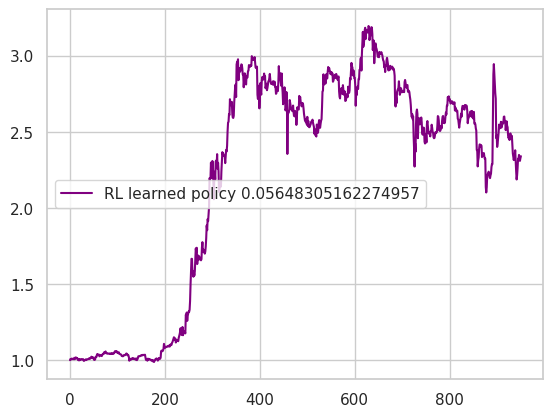

In [104]:

# model = LModel.load_from_checkpoint('lightning_logs/version_13/checkpoints/epoch=49-step=4649.ckpt')
runid = mlflow.search_runs(experiment_ids=[2815], filter_string='tags.mlflow.runName = "RL_run_naive"')['run_id'][0]
path = f'./2815/{runid}/checkpoints/'
final_path = path + os.listdir(path)[0]
model = LModel.load_from_checkpoint(final_path)

def backtest_by_strategy(data, strategy, seq_len, last_w = False):
    # lastw = torch.zeros((7))
    # lastw[0] = 1
    lastw = torch.ones((7))/7
    lastw = lastw.unsqueeze(0).to('cuda:0')
    log_mean =[]
    APV = [1]
    pvector = []
    w = []
    Y = []
    for i in range(1000-seq_len):
        x = data[:,:,i:i+seq_len]/ data[0,:,i+seq_len:i+seq_len+1].repeat((3,1,seq_len))
        y = (data[0,:,i+seq_len]/data[0,:,i+seq_len-1])
        y = torch.cat((torch.tensor([1]), y), dim = 0).to('cuda:0')
        if last_w:        
            new_w = strategy(x.unsqueeze(0).to('cuda:0'), lastw[:,1:].to('cuda:0'))
        else:
            new_w = strategy(x.unsqueeze(0).to('cuda:0').float())
        w.append(np.array(new_w.squeeze().cpu().detach()))
        Y.append(np.array(y.cpu().detach()))
        w_prime = (y * lastw).to('cuda:0')
        w_prime = w_prime/torch.sum(w_prime)
        c = 0.0
        mu = 1 - torch.sum(torch.abs(new_w - w_prime), dim=1) * c
        pv = torch.sum(new_w * y.to('cuda:0') * mu.to('cuda:0'))
        pvector.append(pv)
        log_mean.append(torch.mean(torch.log(torch.sum(new_w * y.to('cuda:0') * mu.to('cuda:0')))).item())
        APV.append(APV[-1]*torch.exp(torch.tensor(log_mean[-1])))
        lastw = new_w
    return APV, log_mean, torch.tensor(pvector), w, Y
model.eval()
APV, log_mean, pv, w, Y = backtest_by_strategy(backtest, model, model.seq_len, False)
sharpe = (torch.mean(pv)-1)/torch.std(pv)
plt.plot(APV, color = 'purple', label = f'RL learned policy {sharpe}')
plt.legend()

### Compare to traditional pf optimization

In [91]:
def simplex_proj(y):
    '''projection of y onto simplex. '''
    m = len(y)
    bget = False

    s = torch.sort(y, descending = True)[0]
    tmpsum = 0.

    for ii in range(m-1):
        tmpsum = tmpsum + s[ii]
        tmax = (tmpsum - 1) / (ii + 1)
        if tmax >= s[ii+1]:
            bget = True
            break

    if not bget:
        tmax = (tmpsum + s[m-1] - 1) / m

    return torch.maximum(torch.tensor(0), y-tmax)

## Define strategies
class buy_and_hold():
    def __init__(self, n):
        self.n = n
    def __call__(self, x, lastw = None):
        new_w = torch.zeros((7)).to('cuda:0')
        new_w[self.n] = 1
        return new_w.unsqueeze(0)

class UCRP():
    def __init__(self):
        pass
    
    def __call__(self, x, lastw = None):
        new_w = torch.ones((7)).to('cuda:0')
        new_w = new_w/torch.sum(new_w)
        return new_w.unsqueeze(0)

class PAMR():
    def __init__(self, epsilon, variant, C):
        self.epsilon = epsilon
        self.C = torch.tensor(C)
        self.variant = variant

    def __call__(self, x, lastw):
        last_rel_price = x[0,-1,:,-1]/x[0,-1,:,-2]
        last_rel_price = torch.cat((torch.tensor([1]).to('cuda:0'), last_rel_price), dim = 0)
        lastw = torch.cat((torch.tensor([1-torch.sum(lastw)]).to('cuda:0'), lastw.squeeze()), dim = 0)

        denom = torch.square(torch.norm(last_rel_price-torch.mean(last_rel_price)))
        diff = torch.dot(lastw.float(), last_rel_price.squeeze().float())- self.epsilon
        le = torch.maximum(torch.tensor(0), diff)

        if self.variant == 0:
            tau = le / denom
        elif self.variant == 1:
            tau = torch.minimum(self.C, le / denom)
        elif self.variant == 2:
            tau = le / (denom + 0.5 / self.C)
            
        tau = torch.minimum(torch.tensor(10000), tau)

        new_w = lastw - tau * (last_rel_price - torch.mean(last_rel_price))
        return simplex_proj(new_w).unsqueeze(0)
        

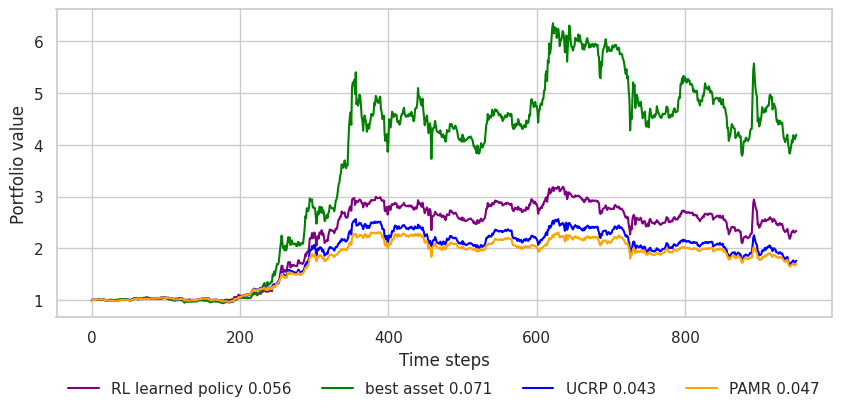

In [101]:
model.eval()
sns.set_style('whitegrid')
plt.figure(figsize=(10,4))
APV, log_mean, pv, w, _ = backtest_by_strategy(backtest, model, model.seq_len, False)
sharpe = (torch.mean(pv)-1)/torch.std(pv)
plt.plot(APV, color = 'purple', label = f'RL learned policy {sharpe:.3f}')
APV, log_mean, pv, _, _ = backtest_by_strategy(backtest, buy_and_hold(5), model.seq_len)
sharpe = (torch.mean(pv)-1)/torch.std(pv)
plt.plot(APV, color = 'green', label = f'best asset {sharpe:.3f}')
APV, log_mean, pv, _,_ = backtest_by_strategy(backtest, UCRP(), model.seq_len)
sharpe = (torch.mean(pv)-1)/torch.std(pv)
plt.plot(APV, color = 'blue', label = f'UCRP {sharpe:.3f}')
APV, log_mean, pv, _,_ = backtest_by_strategy(backtest, PAMR(0.95, 2, 0.5), model.seq_len, True)
sharpe = (torch.mean(pv)-1)/torch.std(pv)
plt.plot(APV, color = 'orange', label = f'PAMR {sharpe:.3f}')
plt.xlabel('Time steps')
plt.ylabel('Portfolio value')
plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.3), ncol = 7, frameon = False)
plt.savefig('APV_plot_model',dpi = 300, transparent = True,  bbox_inches="tight")

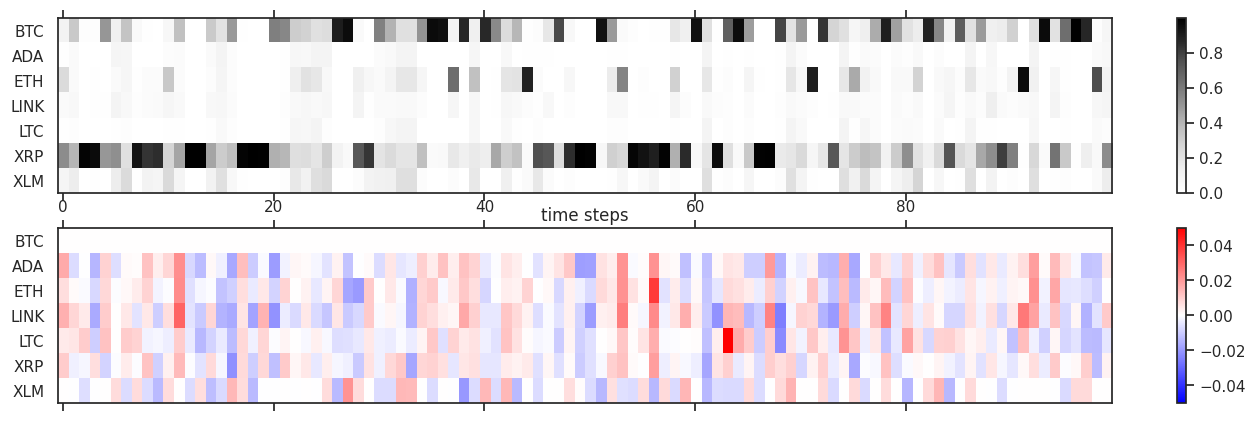

In [99]:
sns.set_style('white')
fig, axs = plt.subplots(2,1,figsize=(17,5), sharex = True)
img0 = axs[0].matshow(np.array(w)[:100].T, cmap=plt.cm.Greys, aspect = 'auto')
axs[0].set_xlabel('time steps')
axs[0].set_yticks(range(7),['BTC']+Coinlist)

img1 = axs[1].matshow(np.array(Y)[:100].T - 1, cmap=plt.cm.bwr, aspect = 'auto', vmin = -0.05, vmax = 0.05 )
axs[1].set_yticks(range(7),['BTC']+ Coinlist)
plt.colorbar(img0)
plt.colorbar(img1)

plt.savefig('weights_distrib_st001',dpi = 300, transparent = True)


## 2.1. Adding transaction fee

In [ ]:
class Dataset(IterableDataset):
    def __init__(self, buffer: 'Buffer', source: str) -> None:
        self.buffer = buffer
        self.source = source

    def __iter__(self) -> Iterable:
        return self

    def __next__(self):
        return self.buffer.next_batch(self.source)


class Buffer(nn.Module):
    def __init__(self,
                 coin_features: torch.tensor,
                 batch_size=50,
                 window_size=50,
                 test_portion=0.15,
                 validation_portion=0.1,
                 sample_bias=0.1,
                 portion_reversed=False,
                 device="cpu"
                 ):
        super(Buffer, self).__init__()
        
        assert coin_features.ndim == 3
        coin_num = coin_features.shape[1]
        period_num = coin_features.shape[2]

        coin_features = torch.tensor(coin_features, device=device)

        # portfolio vector memory
        pvm = torch.full([period_num, coin_num], 1.0 / coin_num, device=device)
        self.register_buffer("_coin_features", coin_features, True)
        self.register_buffer("_pvm", pvm, True)

        self._batch_size = batch_size
        self._window_size = window_size
        self._sample_bias = sample_bias
        self._portion_reversed = portion_reversed
        self._train_idx, self._test_idx, self._val_idx = \
            self._divide_data(period_num, window_size, test_portion,
                              validation_portion, portion_reversed)

        # the count of appended experiences
        self._new_exp_count = 0

    @property
    def train_num(self):
        return len(self._train_idx)

    @property
    def test_num(self):
        return len(self._test_idx)

    @property
    def val_num(self):
        return len(self._val_idx)

    def get_train_set(self):
        return self._pack_samples(self._train_idx)

    def get_test_set(self):
        return self._pack_samples(self._test_idx)

    def get_val_set(self):
        return self._pack_samples(self._val_idx)

    def get_train_dataset(self):
        return Dataset(self, "train")

    def get_test_dataset(self):
        return Dataset(self, "test")

    def get_val_dataset(self):
        return Dataset(self, "val")

    def next_batch(self, source="train"):

        if source == "train":
            start_idx = self._train_idx[0]
            end_idx = self._train_idx[-1]
        elif source == "test":
            start_idx = self._test_idx[0]
            end_idx = self._test_idx[-1]
        elif source == "val":
            start_idx = self._val_idx[0]
            end_idx = self._val_idx[-1]

        batch_start = self._sample_geometric(
            start_idx, end_idx-self._batch_size, self._sample_bias
        )
        batch_idx = list(range(batch_start, batch_start + self._batch_size))
        batch = self._pack_samples(batch_idx)
        return batch

    def _pack_samples(self, index):
        index = np.array(index)
        last_w = self._pvm[index - 1, :]

        def setw(w):
            assert torch.is_tensor(w)
            self._pvm[index, :] = w.to(self._pvm.device).detach()

        batch = torch.stack([
            self._coin_features[:, :, idx:idx + self._window_size + 1]
            for idx in index
        ])
        # features, [batch, feature, coin, time]
        X = batch[:, :, :, :-1]
        norm = X[:, 0:1, :, -1:].repeat((1,3,1,self._window_size))
        X = X/norm
        # price relative vector of the last period, [batch, norm_feature, coin]
        y = batch[:, :, :, -1] / batch[:, 0, None, :, -2]
        return {"X": X, "y": y, "last_w": last_w, "setw": setw}

    @staticmethod
    def _sample_geometric(start, end, bias):
        """
        Generate a index within [start, end) with geometric probability.

        Args:
            bias: A value in (0, 1).
        """
        # sample = np.random.geometric(0.0003)
        # while end - sample < start :
        #     sample = np.random.geometric(0.0003)
        # result = end-sample    
        result = np.random.randint(start, end)
        return result

    @staticmethod
    def _divide_data(period_num,
                     window_size,
                     test_portion,
                     val_portion,
                     portion_reversed):
        """
        Divide training data into three portions, train, test and validation.

        Args:
            period_num: Number of price records in the time dimension.
            window_size: Sliding window size of history price records
            visible to the agent.
            test_portion/val_portion: Percent of these two portions.
            portion_reversed: Whether reverse the order of portions.

        Returns:
            Three np.ndarray type index arrays, train, test, validation.
        """
        train_portion = 1 - test_portion - val_portion
        indices = np.arange(period_num)

        if portion_reversed:
            split_point = np.array(
                [val_portion, val_portion + test_portion]
            )
            split_idx = (split_point * period_num).astype(int)
            val_idx, test_idx, train_idx = np.split(indices, split_idx)
        else:
            split_point = np.array(
                [train_portion, train_portion + test_portion]
            )
            split_idx = (split_point * period_num).astype(int)
            train_idx, test_idx, val_idx = np.split(indices, split_idx)

        # truncate records in the last time window, otherwise we may
        # sample insufficient samples when reaching the last window.
        train_idx = train_idx[:-(window_size + 1)]
        test_idx = test_idx[:-(window_size + 1)]
        val_idx = val_idx[:-(window_size + 1)]

        return train_idx, test_idx, val_idx


In [ ]:
class Model(nn.Module):
    def __init__(self, seq_len):
        super(Model, self).__init__()
        self.seq_len = seq_len

        self.conv = nn.Conv2d(3, 2, (1,3), stride = 1)
        self.relu = nn.ReLU()
        self.conv2 = nn.Conv2d(2, 20, (1,seq_len-2), stride = 1)
        self.conv3 = nn.Conv2d(21, 1, 1)

        self.last_activ = nn.Softmax(dim = 1)
        self.dense = nn.Linear(6,7)
        
        
    def forward(self, x, lastw):
        x = x.float()
        x = self.conv(x)
        x = self.relu(x)
        x = self.conv2(x)
        x = self.relu(x)
        x = torch.concatenate((lastw[:,None,:,None],x),dim=1)
        x = self.conv3(x)
        x = self.relu(x)
        x = x.flatten(start_dim=1)
        # x = torch.concatenate((torch.ones((x.shape[0], 1)).to(device= 'cuda:0'), x), dim = 1)
        x = torch.cat((torch.ones_like(x)[:,0:1],x),dim = 1)
        x = self.last_activ(x)
        return x
    
class TraderTrainer(L.LightningModule):
    def __init__(self, data,  seq_len, batch_size):
        super().__init__()
        self.buffer = Buffer(coin_features = data,batch_size= batch_size,window_size=seq_len,test_portion=0.15,validation_portion=0.15, device='cuda:0')
        self.model = Model(seq_len)
        self.seq_len = seq_len
        self.batch_size = batch_size
        self.save_hyperparameters()

    def train_dataloader(self):
        return DataLoader(dataset=self.buffer.get_train_dataset(),
                          collate_fn=lambda x: x)

    def training_step(self, batch, _batch_idx):
        batch = batch[0]
        y = batch['y']
        new_w = self.model(batch["X"], batch["last_w"])
        batch["setw"](new_w[:, 1:])
        y = torch.cat([torch.ones([y.shape[0], 1], device=y.device),
                      y[:, 0, :]], dim=1)
        w_prime = y * new_w
        w_prime = w_prime / torch.sum(w_prime, dim=1).unsqueeze(-1)
        c = 0.0025
        w_t = w_prime[:-1]
        w_t1 = new_w[1:]
        mu = 1 - torch.sum(torch.abs(w_t1 - w_t), dim=1) * c
        pv_vector = torch.sum(new_w * y, dim=1)*(torch.cat([torch.ones([1], device=mu.device), mu], dim=0))
        log_mean = torch.mean(torch.log(pv_vector))
        self.log('loss', log_mean)
        
        return log_mean
    
    def val_dataloader(self):
        return DataLoader(dataset=self.buffer.get_val_dataset(),
                          collate_fn=lambda x: x)

    def validation_step(self,batch, batch_idx):
        batch = batch[0]
        y = batch['y']
        new_w = self.model(batch["X"], batch["last_w"])
       
        batch["setw"](new_w[:, 1:])
        y = torch.cat([torch.ones([y.shape[0], 1], device=y.device),
                      y[:, 0, :]], dim=1)
        w_prime = y * new_w
        w_prime = w_prime / torch.sum(w_prime, dim=1).unsqueeze(-1)
        c = 0.0025
        w_t = w_prime[:-1]
        w_t1 = new_w[1:]
        mu = 1 - torch.sum(torch.abs(w_t1 - w_t), dim=1) * c
        pv_vector = torch.sum(new_w * y, dim=1)*(torch.cat([torch.ones([1], device=mu.device), mu], dim=0))
        log_mean = torch.mean(torch.log(pv_vector))
        pf_val = torch.prod(pv_vector)
        sharpe_ratio = (torch.mean(pv_vector)-1)/torch.std(pv_vector)
        dict_metrics = {
            'sharpe_ratio' : sharpe_ratio,
            'portfolio_value': pf_val,
        }
        self.log('val_loss', log_mean)
        self.log_dict(dict_metrics)
    
    
    def forward(self, x, last_w):
        return self.model(x, last_w)
    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=0.001, maximize=True)
        return optimizer
    

In [19]:
n_epochs = 5
logger =  MLFlowLogger(experiment_name = 'RL_proj', run_name = f'RL_run_withW', tracking_uri = os.getenv('MLFLOW_TRACKING_URI'), artifact_location = os.getenv('ARTIFACT_URI'))
callbacks = [EarlyStopping(monitor = 'val_loss', patience = 5, mode='max', verbose = True), ModelCheckpoint(monitor = 'val_loss', mode= 'max', save_top_k=1) ]
trainer = L.Trainer(
                    devices = 1, accelerator = 'gpu',  max_epochs = n_epochs, logger = logger, callbacks= callbacks,
                    log_every_n_steps=100, enable_progress_bar=True,  limit_train_batches = 3000, limit_val_batches= 100, max_steps = 100000, 
                    val_check_interval=0.3
                    )

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


In [ ]:
df_all = pd.read_parquet('./data/df_all.parquet')
data = df_all.values.reshape(-1, 6,3)
data = torch.tensor(data)
data = torch.permute(data, (2,1,0))
model = TraderTrainer(data,seq_len=50,batch_size=50)
trainer.fit(model)

/tmp/ipykernel_415230/100703930.py:35: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  coin_features = torch.tensor(coin_features, device=device)
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name   | Type   | Params | Mode 
------------------------------------------
0 | buffer | Buffer | 0      | train
1 | model  | Model  | 2.0 K  | train
------------------------------------------
2.0 K     Trainable params
0         Non-trainable params
2.0 K     Total params
0.008     Total estimated model params size (MB)
8         Modules in train mode
0         Modules in eval mode


/home/jovyan/.conda/envs/GPU/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
/home/jovyan/.conda/envs/GPU/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Epoch 0:  30%|███       | 900/3000 [00:08<00:18, 111.20it/s, v_num=5d2b]

Metric val_loss improved. New best score: -0.000


Epoch 0:  90%|█████████ | 2700/3000 [00:25<00:02, 104.72it/s, v_num=5d2b]

...

Epoch 1:  30%|███       | 900/3000 [00:07<00:18, 114.60it/s, v_num=5d2b] 

Metric val_loss improved by 0.000 >= min_delta = 0.0. New best score: 0.000


Epoch 2:  90%|█████████ | 2700/3000 [00:25<00:02, 105.67it/s, v_num=5d2b]

Monitored metric val_loss did not improve in the last 5 records. Best score: 0.000. Signaling Trainer to stop.


Epoch 2:  90%|█████████ | 2700/3000 [00:26<00:02, 102.22it/s, v_num=5d2b]
🏃 View run RL_run_withW at: https://mlflow-public.models.cardoai.com/#/experiments/2815/runs/4ebf0d64536447d8a625eadc218f5d2b
🧪 View experiment at: https://mlflow-public.models.cardoai.com/#/experiments/2815


In [11]:
model = TraderTrainer.load_from_checkpoint('2815/ba3cbac48ac546568b14304301b729cd/checkpoints/epoch=0-step=1800.ckpt')

/tmp/ipykernel_415230/100703930.py:35: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  coin_features = torch.tensor(coin_features, device=device)


In [28]:
backtest = df_all.iloc[-1000:]
backtest = torch.tensor(backtest.values)
backtest = torch.reshape(backtest, (-1,6,3))
backtest = torch.permute(backtest, (2,1,0))

NameError: name 'df_all' is not defined

In [ ]:
def backtest_by_strategy(data, strategy, seq_len):
    # lastw = torch.zeros((7))
    # lastw[0] = 1
    lastw = torch.ones((7))/7
    lastw = lastw.unsqueeze(0).to('cuda:0')
    log_mean =[]
    APV = [1]
    pvector = []
    w = []
    for i in range(1000-seq_len):
        x = data[:,:,i:i+seq_len]/ data[0,:,i+seq_len:i+seq_len+1].repeat((3,1,seq_len))
        y = (data[0,:,i+seq_len]/data[0,:,i+seq_len-1])
        y = torch.cat((torch.tensor([1]), y), dim = 0).to('cuda:0')
        new_w = strategy(x.unsqueeze(0).to('cuda:0'), lastw[:,1:].to('cuda:0'))
        w.append(np.array(new_w.squeeze().cpu().detach()))
        w_prime = (y * lastw).to('cuda:0')
        w_prime = w_prime/torch.sum(w_prime)
        c = 0.0025
        mu = 1 - torch.sum(torch.abs(new_w - w_prime), dim=1) * c
        pv = torch.sum(new_w * y.to('cuda:0') * mu.to('cuda:0'))
        pvector.append(pv)
        log_mean.append(torch.mean(torch.log(torch.sum(new_w * y.to('cuda:0') * mu.to('cuda:0')))).item())
        APV.append(APV[-1]*torch.exp(torch.tensor(log_mean[-1])))
        lastw = new_w
    return APV, log_mean, torch.tensor(pvector), w


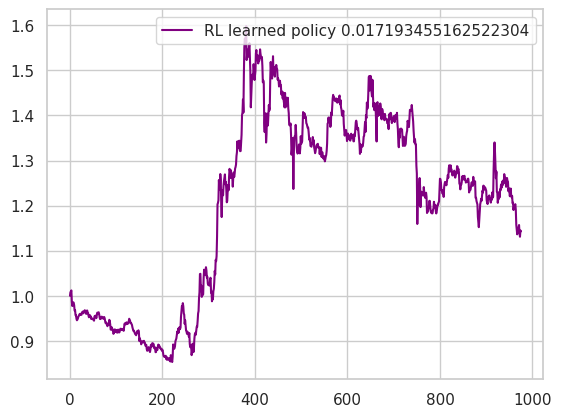

In [15]:
model.eval()
APV, log_mean, pv, w = backtest_by_strategy(backtest, model, model.seq_len)
sharpe = (torch.mean(pv)-1)/torch.std(pv)
plt.plot(APV, color = 'purple', label = f'RL learned policy {sharpe}')
plt.legend()